<a href="https://colab.research.google.com/github/andresmidisabana/AlgNoSupervisados/blob/main/ML_Ingesta_Preparacion_Etiquetado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sección 1 — Ingesta, Preparación y Etiquetado

## 0. Imports

In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.simplefilter("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 1. Ingesta

In [ ]:
FILENAME = "logs_sanitized.log"

CANDIDATE_PATHS = [
    Path(FILENAME),
    Path("/content") / FILENAME,
    Path("/tmp") / FILENAME,
]


def load_raw_logs() -> list[str]:
    for path in CANDIDATE_PATHS:
        if path.exists():
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                lines = [ln.rstrip("\n") for ln in f if ln.strip()]
            print(f"Fuente: {path.resolve()}")
            return lines

    raise FileNotFoundError(
        f"No se encontró '{FILENAME}'. Rutas probadas:\n"
        + "\n".join(f"  - {p}" for p in CANDIDATE_PATHS)
    )


raw_logs = load_raw_logs()
print(f"Total de líneas crudas: {len(raw_logs):,}")

Fuente: /content/logs_sanitized.log
Total de líneas crudas: 9,795


## 2. Parser

In [ ]:
APACHE_COMBINED_RE = re.compile(
    r'(?P<ip>\S+) \S+ \S+ '
    r'\[(?P<timestamp>[^\]]+)\] '
    r'"(?P<method>[A-Z]+) (?P<path>.*?) (?P<protocol>HTTP/\S+)" '
    r'(?P<status>\d{3}) (?P<bytes>\d+) '
    r'"(?P<referer>[^"]*)" '
    r'"(?P<user_agent>[^"]*)" '
    r'(?P<response_time>\d+)'
)


def parse_log(line: str) -> dict | None:
    m = APACHE_COMBINED_RE.match(line)
    return m.groupdict() if m else None


parsed = [parse_log(ln) for ln in raw_logs]
parsed_ok   = [p for p in parsed if p is not None]
parsed_fail = [ln for ln, p in zip(raw_logs, parsed) if p is None]

print(f"Parseadas OK        : {len(parsed_ok):,} ({len(parsed_ok)/max(len(raw_logs),1):.2%})")
print(f"Líneas no parseadas : {len(parsed_fail):,}")

df = pd.DataFrame(parsed_ok)
df.head(3)

Parseadas OK        : 9,795 (100.00%)
Líneas no parseadas : 0


,ip,timestamp,method,path,protocol,status,bytes,referer,user_agent,response_time
0,216.73.216.23,22/Apr/2026:09:17:59 +0000,GET,/sitemap.xml,HTTP/1.0,200,728,http://compromised.site/sitemap.xml,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Gecko; compatible; Claude-SearchBot/1.0; +searchbot@anthropic.com)",129405
1,170.106.181.163,22/Apr/2026:09:27:12 +0000,GET,/wp-json/oembed/1.0/embed?url=https%3A%2F%2Fcompromised.site%2Fblog%2Fpin-up-azrbaycann-n-yax-kazinosu-rsmi-sayt1069...,HTTP/1.0,200,2947,-,"Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/13.0.3 Mob...",101268
2,207.180.11.159,22/Apr/2026:09:28:41 +0000,GET,/wp-json/oembed/1.0/embed?url=https%3A%2F%2Fcompromised.site%2Fprospective-families%2Ftraveling-to-camp%2F&format=xml,HTTP/1.0,200,1682,-,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36",173199


## 3. Tipado y limpieza

In [ ]:
df["status"]        = pd.to_numeric(df["status"], errors="coerce").astype("Int64")
df["bytes"]         = pd.to_numeric(df["bytes"], errors="coerce").astype("Int64")
df["response_time"] = pd.to_numeric(df["response_time"], errors="coerce")
df["response_time_seconds"] = df["response_time"] / 1_000_000

df["timestamp"] = pd.to_datetime(
    df["timestamp"], format="%d/%b/%Y:%H:%M:%S %z", errors="coerce"
)

df["referer"] = df["referer"].replace({"-": pd.NA, "": pd.NA})

before = len(df)
df = df.dropna(subset=["ip", "method", "path", "status", "timestamp"]).reset_index(drop=True)
print(f"Filas eliminadas por nulos críticos: {before - len(df)}")
print(f"Filas finales: {len(df):,}")

Filas eliminadas por nulos críticos: 0
Filas finales: 9,795


## 4. Variables derivadas

In [ ]:
df["hour"]           = df["timestamp"].dt.hour
df["dayofweek"]      = df["timestamp"].dt.dayofweek
df["minute"]         = df["timestamp"].dt.minute

df["path_length"]    = df["path"].str.len()
df["path_n_slashes"] = df["path"].str.count("/")
df["has_query"]      = df["path"].str.contains(r"\?", regex=True).astype(int)
df["query_length"]   = df["path"].str.split("?").str[1].fillna("").str.len()
df["path_n_pct"]     = df["path"].str.count("%")

df["is_error"]       = (df["status"] >= 400).astype(int)

df[[
    "hour", "dayofweek", "path_length", "path_n_slashes",
    "has_query", "query_length", "path_n_pct", "is_error"
]].describe().round(2)

,hour,dayofweek,path_length,path_n_slashes,has_query,query_length,path_n_pct,is_error
count,9795.00,9795.00,9795.00,9795.00,9795.00,9795.00,9795.00,9795.0
mean,12.10,2.96,44.28,3.17,0.25,17.25,1.10,0.0
std,7.57,2.24,38.80,2.35,0.43,37.09,4.36,0.0
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.0
25%,4.00,1.00,13.00,1.00,0.00,0.00,0.00,0.0
50%,14.00,3.00,26.00,2.00,0.00,0.00,0.00,0.0
75%,18.00,5.00,68.00,4.00,0.00,0.00,0.00,0.0
max,23.00,6.00,631.00,10.00,1.00,605.00,159.00,0.0


## 5. EDA

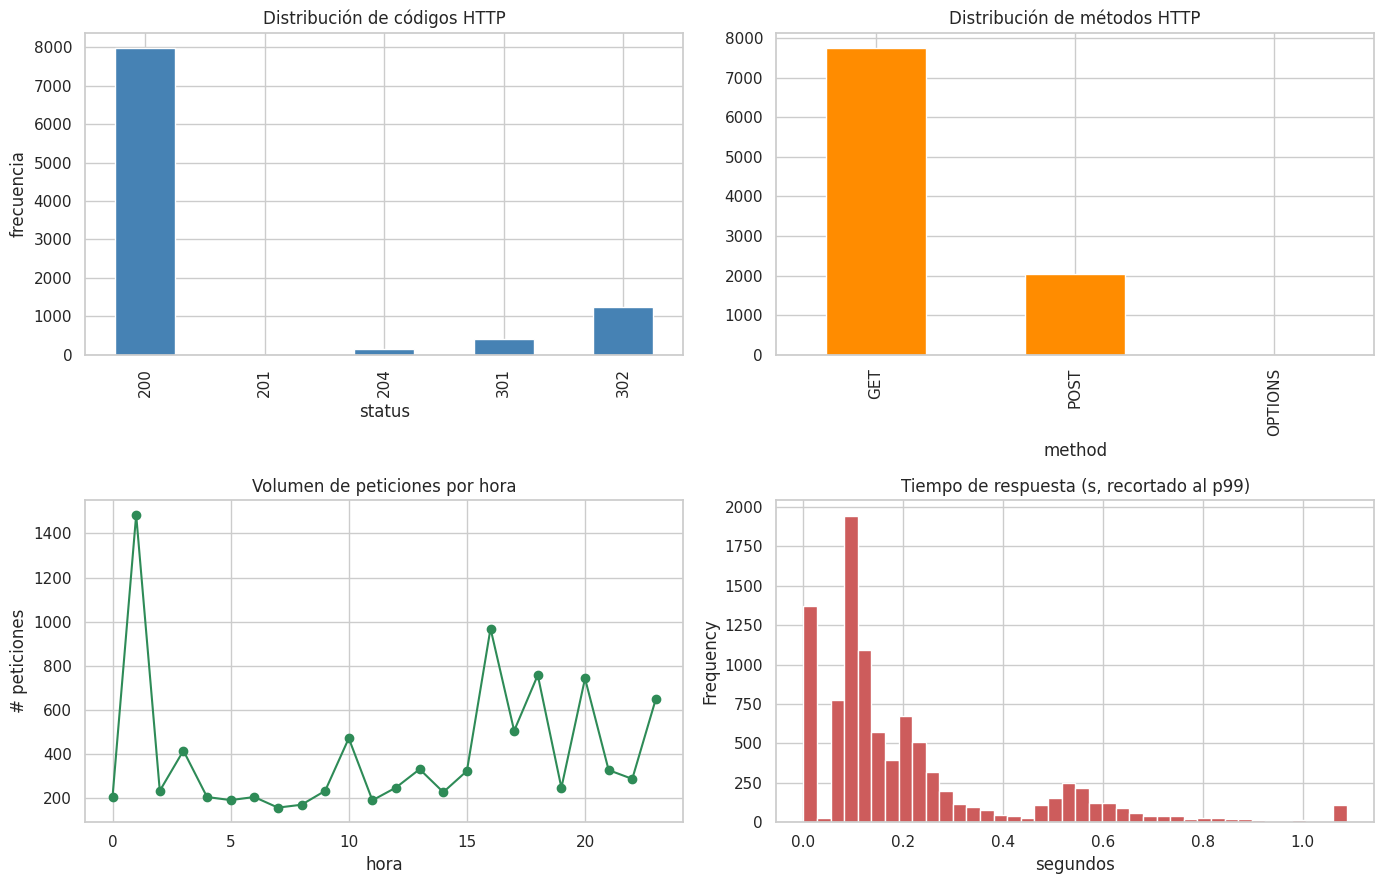

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df["status"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribución de códigos HTTP"); axes[0, 0].set_xlabel("status"); axes[0, 0].set_ylabel("frecuencia")

df["method"].value_counts().plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Distribución de métodos HTTP")

df.groupby("hour").size().plot(kind="line", ax=axes[1, 0], marker="o", color="seagreen")
axes[1, 0].set_title("Volumen de peticiones por hora"); axes[1, 0].set_xlabel("hora"); axes[1, 0].set_ylabel("# peticiones")

df["response_time_seconds"].clip(upper=df["response_time_seconds"].quantile(0.99)).plot(
    kind="hist", bins=40, ax=axes[1, 1], color="indianred"
)
axes[1, 1].set_title("Tiempo de respuesta (s, recortado al p99)"); axes[1, 1].set_xlabel("segundos")

plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 user-agents:")
print(df["user_agent"].value_counts().head(10).to_string())
print()
print("Top 10 paths:")
print(df["path"].value_counts().head(10).to_string())

Top 10 user-agents:
user_agent
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36                                                                    1313
Mozilla/5.0 (Linux; Android 7.0;) AppleWebKit/537.36 (HTML, like Gecko) Mobile Safari/537.36 (compatible; PetalBot;+https://webmaster.petalsearch.com/site/petalbot)      952
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36                                                     801
Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Gecko; compatible; Amzn-SearchBot/0.1) Chrome/119.0.6045.214 Safari/537.36                                                    557
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/143.0.0.0 Safari/537.36                                                           463
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/26

## 6. Etiquetado heurístico

In [ ]:
BOT_KEYWORDS     = re.compile(r"\b(bot|crawler|spider|searchbot|petalbot|sogou|googlebot|bingbot|amzn|yandex)", re.IGNORECASE)
WP_INTERNAL_RE   = re.compile(r"^WordPress/", re.IGNORECASE)
WP_MGMT_AGENTS   = re.compile(r"\b(ManageWP|iThemes-Sync|MainWP|WP\s*Remote)\b", re.IGNORECASE)
OEMBED_PATH_RE   = re.compile(r"/wp-json/oembed/", re.IGNORECASE)


def label_log(row) -> str:
    path = str(row["path"])
    ua   = str(row["user_agent"])

    if OEMBED_PATH_RE.search(path):
        return "oembed_request"
    if WP_MGMT_AGENTS.search(ua):
        return "wp_management"
    if WP_INTERNAL_RE.search(ua):
        return "wp_internal"
    if BOT_KEYWORDS.search(ua):
        return "search_bot"
    return "legitimate_user"


df["label"] = df.apply(label_log, axis=1)
df["label"].value_counts()

,count
label,
legitimate_user,6755
search_bot,1686
oembed_request,1094
wp_internal,239
wp_management,21


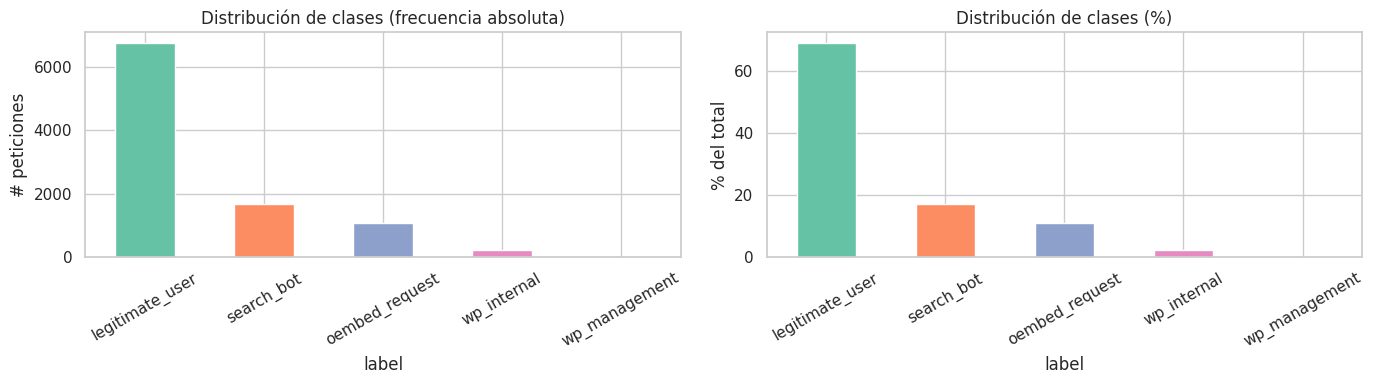


Desbalance (mayoría / minoría): 321.7x


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df["label"].value_counts()
counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2", len(counts)))
axes[0].set_title("Distribución de clases (frecuencia absoluta)")
axes[0].set_ylabel("# peticiones"); axes[0].tick_params(axis="x", rotation=30)

(counts / counts.sum() * 100).plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", len(counts)))
axes[1].set_title("Distribución de clases (%)")
axes[1].set_ylabel("% del total"); axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"\nDesbalance (mayoría / minoría): {counts.max() / counts.min():.1f}x")

In [ ]:
for cls in df["label"].unique():
    print(f"\n=== {cls} ===")
    n = min(3, (df["label"] == cls).sum())
    sample = df[df["label"] == cls].sample(n, random_state=42)
    print(sample[["method", "path", "status", "user_agent"]].to_string(index=False, max_colwidth=80))


=== search_bot ===
method                                                                             path  status                                                                       user_agent
   GET /?s=WA%2B0812%2B2782%2B5310%2BFee%2BPembuatan%2BMolding%2BDinding%2BKamar%2BW...     200 Mozilla/5.0 (Linux; Android 7.0;) AppleWebKit/537.36 (KHTML, like Gecko) Mobi...
   GET                                                          /blog/outdoor-adventure     301 Mozilla/5.0 (Linux; Android 7.0;) AppleWebKit/537.36 (HTML, like Gecko) Mobil...
   GET                                                               /blog/tag/succeed/     200 Mozilla/5.0 (Linux; Android 7.0;) AppleWebKit/537.36 (KHTML, like Gecko) Mobi...

=== oembed_request ===
method                                                                             path  status                                                                       user_agent
   GET /wp-json/oembed/1.0/embed?format=xml&url=https://compromised.sit

## 7. Guardar dataset

In [ ]:
OUTPUT_CSV = Path("logs_processed.csv")
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Guardado: {OUTPUT_CSV.resolve()} ({OUTPUT_CSV.stat().st_size/1024:.1f} KB)")
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]} | Clases: {sorted(df['label'].unique())}")

Guardado: /content/logs_processed.csv (3173.8 KB)
Filas: 9,795 | Columnas: 21 | Clases: ['legitimate_user', 'oembed_request', 'search_bot', 'wp_internal', 'wp_management']
